In [1]:
from pathlib import Path
from typing import Optional, Any, Union

import numpy as np
import polars as pl
import pandas as pd

# plotting
import matplotlib.pyplot as plt
import plotly.express as px
from dash import Dash, dcc, html, Input, Output, State, callback_context
import plotly.graph_objects as go

# scipy
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# muutils
import muutils.tensor_info
from muutils.dbg import dbg, dbg_tensor

# attention-motifs
from attention_motifs.features.analysis import nan_stats, filter_data, normalize_data
from attention_motifs.features.plotting import (
	plot_correlation_matrix,
	plot_embedding,
	apply_pca,
)

muutils.tensor_info.DEFAULT_SETTINGS["colored"] = True
# pl.set_option('display.max_rows', 200)
# pl.set_option('display.max_columns', 200)

In [2]:
# DATA: pl.DataFrame = pl.DataFrame(jsonl_load("../data/scalar_features.jsonl"))

DATA: pl.DataFrame = pl.read_ndjson(Path("../data/features/scalar_features_fixed.jsonl"))

In [3]:
DATA.head()

feat.gram.skew.beta_hist.hist.raw.skewness,feat.gram.row.beta_hist.hist.raw.skewness,feat.gram.col.beta_hist.hist.raw.L2_norm,feat.gram.row.beta_hist.hist.raw.mean,feat.markov_transition.env.lower.intercept,feat.gram.row.beta_hist.hist.raw.entropy,feat.gram.col.beta_hist.hist.raw.linreg.intercept,feat.gram.skew.beta_hist.hist.raw.variance,feat.markov_transition.time.linreg.intercept,feat.gram.skew.beta_hist.hist.raw.L1_norm,feat.gram.col.beta_hist.hist.raw.entropy,feat.log.gram.skew.beta_hist.hist.raw.median,feat.markov_transition.time.L2_norm,feat.gram.row.beta_hist.hist.raw.linreg.r2,feat.diag.entropy,feat.diag.psd_total_power,feat.markov_transition.diff.linreg.slope,feat.gram.col.beta_hist.hist.raw.zero_crossing_rate,feat.markov_transition.time.skewness,feat.gram.row.beta_hist.hist.raw.rms,feat.gram.skew.beta_hist.hist.raw.linreg.slope,feat.first_tok.entropy,feat.markov_transition.diff.kurtosis,feat.markov_transition.time.linreg.r2,feat.markov_transition.diff.mean,feat.markov_transition.env.upper.r2,feat.gram.skew.beta_hist.hist.raw.linreg.intercept,feat.log.gram.row.beta_hist.hist.raw.linreg.intercept,feat.first_tok.L2_norm,feat.gram.col.beta_hist.hist.raw.L1_norm,feat.gram.skew.beta_hist.hist.raw.autocorr_lag1,feat.log.gram.skew.beta_hist.hist.raw.energy,feat.diag.L2_norm,feat.gram.skew.beta_hist.hist.raw.energy,feat.log.gram.row.beta_hist.hist.raw.kurtosis,feat.log.gram.col.beta_hist.hist.raw.linreg.slope,feat.gram.col.beta_hist.hist.raw.psd_total_power,…,feat.log.gram.row.beta_hist.hist.raw.linreg.r2,feat.log.gram.skew.beta_hist.hist.raw.linreg.intercept,feat.first_tok.zero_crossing_rate,feat.markov_transition.diff.linreg.r2,feat.gram.row.beta_hist.hist.raw.linreg.intercept,feat.gram.col.beta_hist.hist.raw.autocorr_lag1,feat.log.gram.col.beta_hist.hist.raw.mean,feat.first_tok.psd_total_power,feat.markov_transition.time.psd_total_power,feat.log.gram.col.beta_hist.hist.raw.linreg.r2,feat.markov_transition.diff.L1_norm,feat.log.gram.skew.beta_hist.hist.raw.linreg.r2,feat.log.gram.row.beta_hist.hist.raw.zero_crossing_rate,feat.gram.skew.beta_hist.hist.raw.linreg.r2,feat.log.gram.row.beta_hist.hist.raw.rms,feat.gram.col.beta_hist.hist.raw.mean,feat.gram.skew.beta_hist.hist.raw.zero_crossing_rate,feat.log.gram.skew.beta_hist.hist.raw.zero_crossing_rate,feat.gram.row.beta_hist.hist.raw.median,feat.markov_transition.time.energy,feat.first_tok.skewness,feat.markov_transition.diff.L2_norm,feat.markov_transition.time.variance,feat.markov_transition.diff.entropy,feat.diag.std,feat.first_tok.std,feat.first_tok.rms,feat.markov_transition.diff.rms,feat.first_tok.L1_norm,feat.first_tok.energy,feat.first_tok.linreg.r2,feat.gram.row.beta_hist.hist.raw.L2_norm,feat.gram.col.beta_hist.hist.raw.rms,feat.log.gram.row.beta_hist.hist.raw.psd_total_power,feat.markov_transition.time.linreg.slope,feat.first_tok.kurtosis,feat.log.gram.col.beta_hist.hist.raw.psd_total_power
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
4.845672,1.094303,16.632153,20.142488,0.0,2.32782,131.525631,11563.263566,0.0,35.058429,1.350188,0.22674,0.0,0.825639,2.15858,1.596638,-0.000466,0.0,null,30.837409,-5.56048,1.140814,108.008929,0.0,0.00885,1.0,121.245875,-0.290582,0.017348,39.319073,0.742355,317.777149,0.022139,397792.161079,23.333774,0.02949,40381.852535,…,0.133926,1.792928,0.0,0.026316,55.760361,0.94515,0.164973,0.733353,0.0,0.144661,0.00885,0.029031,0.0,0.235303,0.756456,39.319073,0.0,0.0,8.855091,0.0,3.412402,0.00885,0.0,0.073066,0.165037,0.169565,0.185231,0.094072,0.076226,3.911398,0.303453,5.451335,94.085666,0.859375,0.0,12.67031,0.878773
5.237281,4.415902,23.761189,29.286952,0.0,1.009186,123.309449,19205.378404,0.0,34.15348,0.39979,0.540372,0.0,0.314078,2.593486,7.588164,-0.000466,0.0,null,77.264035,-5.782257,0.56

In [4]:
# print unique values for columns which start with "activations"
print(f"{DATA['activation.model'].unique() = }")

DATA['activation.model'].unique() = shape: (6,)
Series: 'activation.model' [str]
[
	"gemma-2b"
	"pythia-14m"
	"pythia-1b"
	"gpt2-medium"
	"gpt2-small"
	"tiny-stories-1M"
]


In [5]:
for col in DATA.columns:
	if col.startswith("activation"):
		print(f"{col = }")

col = 'activation.layer'
col = 'activation.cache_key'
col = 'activation.model'
col = 'activation.prompt'
col = 'activation.cls'
col = 'activation.head'


In [6]:
DATA.describe()

statistic,feat.gram.skew.beta_hist.hist.raw.skewness,feat.gram.row.beta_hist.hist.raw.skewness,feat.gram.col.beta_hist.hist.raw.L2_norm,feat.gram.row.beta_hist.hist.raw.mean,feat.markov_transition.env.lower.intercept,feat.gram.row.beta_hist.hist.raw.entropy,feat.gram.col.beta_hist.hist.raw.linreg.intercept,feat.gram.skew.beta_hist.hist.raw.variance,feat.markov_transition.time.linreg.intercept,feat.gram.skew.beta_hist.hist.raw.L1_norm,feat.gram.col.beta_hist.hist.raw.entropy,feat.log.gram.skew.beta_hist.hist.raw.median,feat.markov_transition.time.L2_norm,feat.gram.row.beta_hist.hist.raw.linreg.r2,feat.diag.entropy,feat.diag.psd_total_power,feat.markov_transition.diff.linreg.slope,feat.gram.col.beta_hist.hist.raw.zero_crossing_rate,feat.markov_transition.time.skewness,feat.gram.row.beta_hist.hist.raw.rms,feat.gram.skew.beta_hist.hist.raw.linreg.slope,feat.first_tok.entropy,feat.markov_transition.diff.kurtosis,feat.markov_transition.time.linreg.r2,feat.markov_transition.diff.mean,feat.markov_transition.env.upper.r2,feat.gram.skew.beta_hist.hist.raw.linreg.intercept,feat.log.gram.row.beta_hist.hist.raw.linreg.intercept,feat.first_tok.L2_norm,feat.gram.col.beta_hist.hist.raw.L1_norm,feat.gram.skew.beta_hist.hist.raw.autocorr_lag1,feat.log.gram.skew.beta_hist.hist.raw.energy,feat.diag.L2_norm,feat.gram.skew.beta_hist.hist.raw.energy,feat.log.gram.row.beta_hist.hist.raw.kurtosis,feat.log.gram.col.beta_hist.hist.raw.linreg.slope,…,feat.log.gram.row.beta_hist.hist.raw.linreg.r2,feat.log.gram.skew.beta_hist.hist.raw.linreg.intercept,feat.first_tok.zero_crossing_rate,feat.markov_transition.diff.linreg.r2,feat.gram.row.beta_hist.hist.raw.linreg.intercept,feat.gram.col.beta_hist.hist.raw.autocorr_lag1,feat.log.gram.col.beta_hist.hist.raw.mean,feat.first_tok.psd_total_power,feat.markov_transition.time.psd_total_power,feat.log.gram.col.beta_hist.hist.raw.linreg.r2,feat.markov_transition.diff.L1_norm,feat.log.gram.skew.beta_hist.hist.raw.linreg.r2,feat.log.gram.row.beta_hist.hist.raw.zero_crossing_rate,feat.gram.skew.beta_hist.hist.raw.linreg.r2,feat.log.gram.row.beta_hist.hist.raw.rms,feat.gram.col.beta_hist.hist.raw.mean,feat.gram.skew.beta_hist.hist.raw.zero_crossing_rate,feat.log.gram.skew.beta_hist.hist.raw.zero_crossing_rate,feat.gram.row.beta_hist.hist.raw.median,feat.markov_transition.time.energy,feat.first_tok.skewness,feat.markov_transition.diff.L2_norm,feat.markov_transition.time.variance,feat.markov_transition.diff.entropy,feat.diag.std,feat.first_tok.std,feat.first_tok.rms,feat.markov_transition.diff.rms,feat.first_tok.L1_norm,feat.first_tok.energy,feat.first_tok.linreg.r2,feat.gram.row.beta_hist.hist.raw.L2_norm,feat.gram.col.beta_hist.hist.raw.rms,feat.log.gram.row.beta_hist.hist.raw.psd_total_power,feat.markov_transition.time.linreg.slope,feat.first_tok.kurtosis,feat.log.gram.col.beta_hist.hist.raw.psd_total_power
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,829.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,…,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,123043.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,

In [7]:
nan_stats(DATA)

feature,count
str,u32
"""feat.markov_transition.time.sk…",123043
"""feat.markov_transition.time.ku…",123043
"""feat.gram.skew.beta_hist.hist.…",0
"""feat.gram.row.beta_hist.hist.r…",0
"""feat.gram.col.beta_hist.hist.r…",0
…,…
"""feat.gram.col.beta_hist.hist.r…",0
"""feat.log.gram.row.beta_hist.hi…",0
"""feat.markov_transition.time.li…",0


In [8]:
# because those have nan
DATA_FILTERED: pl.DataFrame = filter_data(
	DATA, remove_models=["tiny-stories-1M", "pythia-14m"]
)
nan_stats(DATA_FILTERED)

Removing 2 models
Models: ['tiny-stories-1M', 'pythia-14m']
Removed 19456/123872 rows
Removing 37/176 cols
feat.markov_transition.env.lower.intercept                   μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.markov_transition.time.linreg.intercept                 μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.markov_transition.time.L2_norm                          μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.gram.col.beta_hist.hist.raw.zero_crossing_rate          μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.markov_transition.time.skewness                         🚨 all NaN shape=104416 dtype=float64
feat.markov_transition.time.linreg.r2                        μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.markov_transition.env.upper.r2                          μ=1.00 σ=0.00 x̃=1.00 R=[1.00,1.00] shape=104416 dtype=float64
feat.markov_transition.diff.zero_crossing_rate     

[ /home/miv/projects/attn/attention-motifs/attention_motifs/features/analysis.py:49 ] remove_cols = ['feat.markov_transition.env.lower.intercept', 'feat.markov_transition.time.linreg.intercept', 'feat.markov_transition.time.L2_norm', 'feat.gram.col.beta_hist.hist.raw.zero_crossing_rate', 'feat.markov_transition.time.skewness', 'feat.markov_transition.time.linreg.r2', 'feat.markov_transition.env.upper.r2', 'feat.markov_transition.diff.zero_crossing_rate', 'feat.markov_transition.env.upper.slope', 'feat.markov_transition.time.entropy', 'feat.markov_transition.time.kurtosis', 'feat.markov_transition.time.zero_crossing_rate', 'feat.markov_transition.time.median', 'feat.markov_transition.time.L1_norm', 'feat.markov_transition.diff.median', 'feat.log.gram.col.beta_hist.hist.raw.zero_crossing_rate', 'feat.log.gram.col.beta_hist.hist.raw.median', 'feat.diag.zero_crossing_rate', 'feat.markov_transition.time.mean', 'feat.markov_transition.time.std', 'feat.markov_transition.env.lower.slope', 'fea

feature,count
str,u32
"""feat.gram.skew.beta_hist.hist.…",0
"""feat.gram.row.beta_hist.hist.r…",0
"""feat.gram.col.beta_hist.hist.r…",0
"""feat.gram.row.beta_hist.hist.r…",0
"""feat.gram.row.beta_hist.hist.r…",0
…,…
"""feat.gram.row.beta_hist.hist.r…",0
"""feat.gram.col.beta_hist.hist.r…",0
"""feat.log.gram.row.beta_hist.hi…",0


[ /home/miv/projects/attn/attention-motifs/attention_motifs/features/plotting.py:32 ] corr_mat: μ=0.02 σ=0.44 x̃=-0.01 R=[-1.00,1.00] ℙ=|▁▂▅█▄▂▂| shape=(139,139) dtype=float64


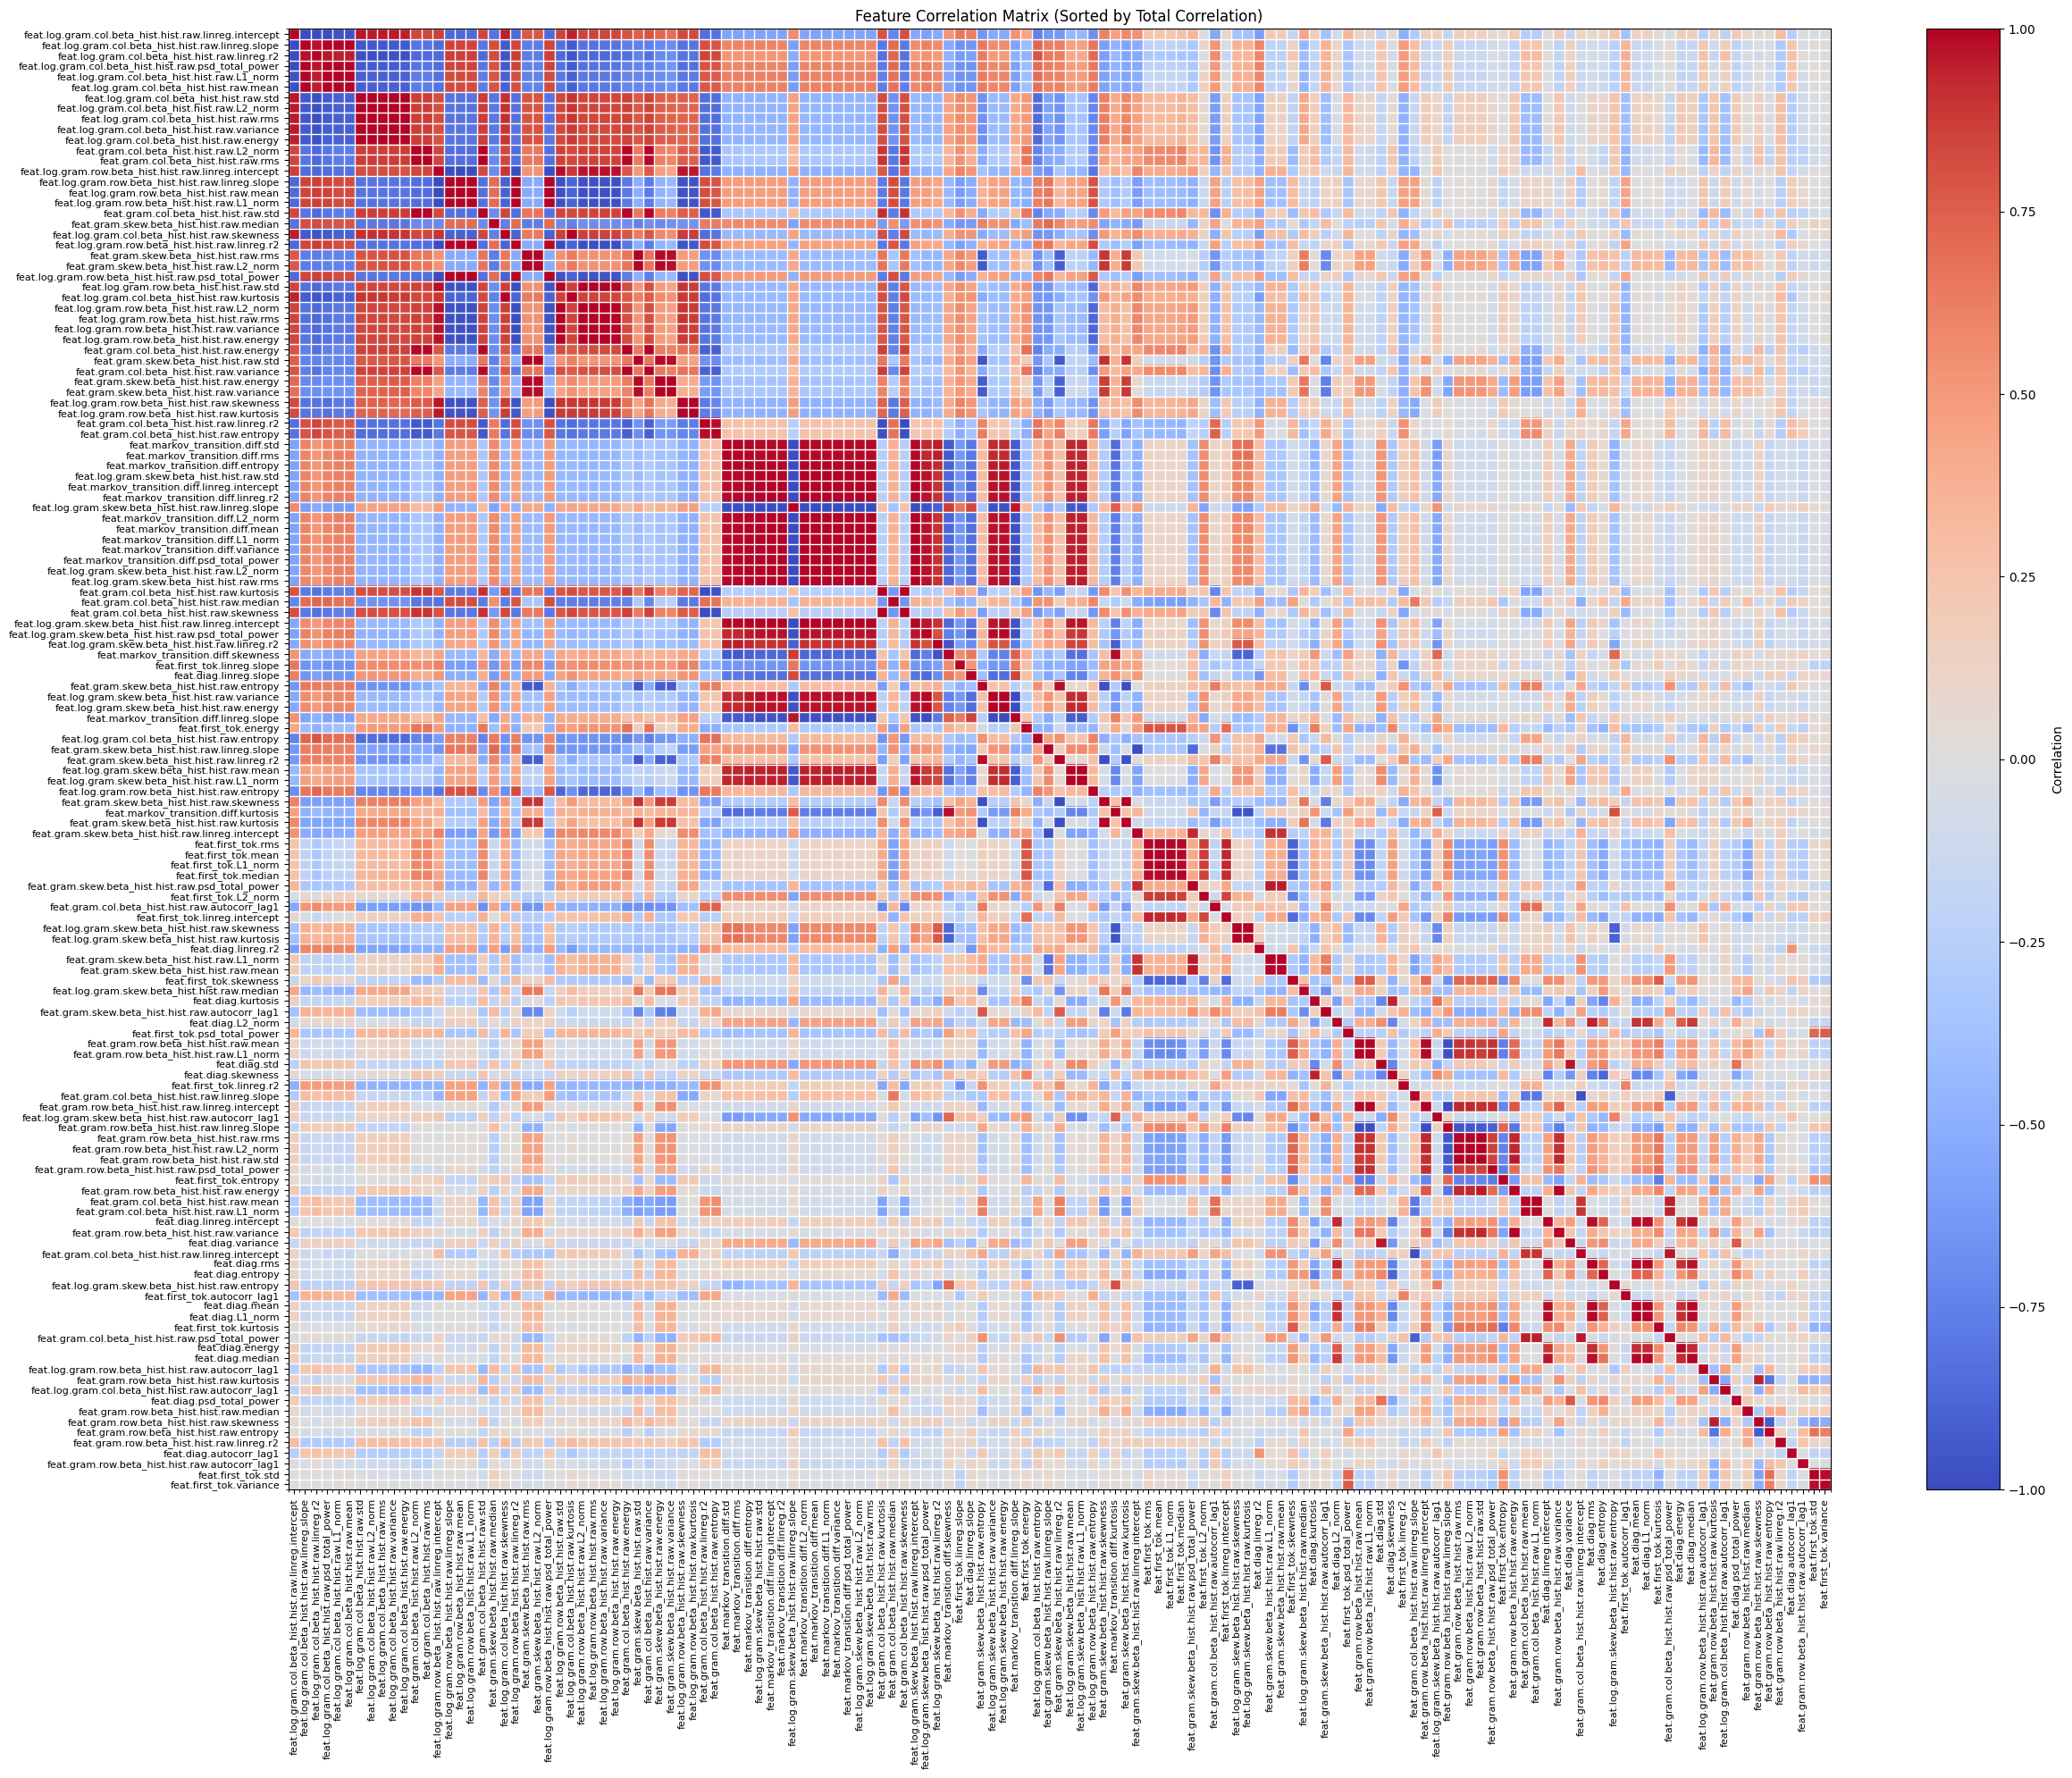

In [9]:
# Pick feature columns
FEATURE_COLS: list[str] = [
	col for col in DATA_FILTERED.columns if col.startswith("feat.")
]

# Plot correlation matrix
plot_correlation_matrix(DATA_FILTERED, FEATURE_COLS)

In [10]:
DATA_SCALED: pl.DataFrame = normalize_data(DATA_FILTERED, FEATURE_COLS)
DATA_SCALED

# plot_correlation_matrix(DATA_SCALED, FEATURE_COLS)

feat.gram.skew.beta_hist.hist.raw.skewness,feat.gram.row.beta_hist.hist.raw.skewness,feat.gram.col.beta_hist.hist.raw.L2_norm,feat.gram.row.beta_hist.hist.raw.mean,feat.gram.row.beta_hist.hist.raw.entropy,feat.gram.col.beta_hist.hist.raw.linreg.intercept,feat.gram.skew.beta_hist.hist.raw.variance,feat.gram.skew.beta_hist.hist.raw.L1_norm,feat.gram.col.beta_hist.hist.raw.entropy,feat.log.gram.skew.beta_hist.hist.raw.median,feat.gram.row.beta_hist.hist.raw.linreg.r2,feat.diag.entropy,feat.diag.psd_total_power,feat.markov_transition.diff.linreg.slope,feat.gram.row.beta_hist.hist.raw.rms,feat.gram.skew.beta_hist.hist.raw.linreg.slope,feat.first_tok.entropy,feat.markov_transition.diff.kurtosis,feat.markov_transition.diff.mean,feat.gram.skew.beta_hist.hist.raw.linreg.intercept,feat.log.gram.row.beta_hist.hist.raw.linreg.intercept,feat.first_tok.L2_norm,feat.gram.col.beta_hist.hist.raw.L1_norm,feat.gram.skew.beta_hist.hist.raw.autocorr_lag1,feat.log.gram.skew.beta_hist.hist.raw.energy,feat.diag.L2_norm,feat.gram.skew.beta_hist.hist.raw.energy,feat.log.gram.row.beta_hist.hist.raw.kurtosis,feat.log.gram.col.beta_hist.hist.raw.linreg.slope,feat.gram.col.beta_hist.hist.raw.psd_total_power,feat.log.gram.skew.beta_hist.hist.raw.mean,feat.log.gram.skew.beta_hist.hist.raw.entropy,feat.markov_transition.diff.variance,feat.log.gram.row.beta_hist.hist.raw.L2_norm,feat.diag.linreg.r2,feat.log.gram.col.beta_hist.hist.raw.variance,feat.log.gram.col.beta_hist.hist.raw.rms,…,feat.gram.col.beta_hist.hist.raw.linreg.r2,feat.log.gram.row.beta_hist.hist.raw.mean,feat.log.gram.row.beta_hist.hist.raw.energy,feat.log.gram.col.beta_hist.hist.raw.L2_norm,feat.gram.row.beta_hist.hist.raw.linreg.slope,feat.gram.col.beta_hist.hist.raw.linreg.slope,feat.log.gram.skew.beta_hist.hist.raw.psd_total_power,feat.log.gram.row.beta_hist.hist.raw.skewness,feat.log.gram.row.beta_hist.hist.raw.linreg.r2,feat.log.gram.skew.beta_hist.hist.raw.linreg.intercept,feat.markov_transition.diff.linreg.r2,feat.gram.row.beta_hist.hist.raw.linreg.intercept,feat.gram.col.beta_hist.hist.raw.autocorr_lag1,feat.log.gram.col.beta_hist.hist.raw.mean,feat.first_tok.psd_total_power,feat.log.gram.col.beta_hist.hist.raw.linreg.r2,feat.markov_transition.diff.L1_norm,feat.log.gram.skew.beta_hist.hist.raw.linreg.r2,feat.gram.skew.beta_hist.hist.raw.linreg.r2,feat.log.gram.row.beta_hist.hist.raw.rms,feat.gram.col.beta_hist.hist.raw.mean,feat.gram.row.beta_hist.hist.raw.median,feat.first_tok.skewness,feat.markov_transition.diff.L2_norm,feat.markov_transition.diff.entropy,feat.diag.std,feat.first_tok.std,feat.first_tok.rms,feat.markov_transition.diff.rms,feat.first_tok.L1_norm,feat.first_tok.energy,feat.first_tok.linreg.r2,feat.gram.row.beta_hist.hist.raw.L2_norm,feat.gram.col.beta_hist.hist.raw.rms,feat.log.gram.row.beta_hist.hist.raw.psd_total_power,feat.first_tok.kurtosis,feat.log.gram.col.beta_hist.hist.raw.psd_total_power
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1.141701,-1.254955,0.870882,-0.288697,1.455366,-0.337689,0.987323,-0.692114,-1.024035,1.532475,0.87097,0.963007,1.450932,0.305812,-0.32214,0.060201,0.604305,-0.057261,-0.266285,-0.252545,0.724929,0.104872,-0.688287,-0.663572,-0.30592,0.28935,0.964072,0.473904,-0.82196,-0.465602,-0.008704,-0.339936,-0.266285,0.839435,-0.986983,0.988711,0.970525,…,-0.792824,-0.7244,0.862457,0.970525,0.279448,0.159702,-0.392105,0.493229,-0.735166,-0.159618,-0.264634,-0.283626,-0.485985,-0.818746,0.489934,-0.863237,-0.266285,0.175968,-1.11468,0.839435,-0.688287,0.55133,-0.631021,-0.266285,-0.245457,1.713928,0.833364,0.274522,-0.21145,0.24403,0.075595,-0.77165,-0.32214,0.870882,-0.687398,-0.375439,-0.780488
1.255822,-0.22357,1.32667,0.343294,0.584242,-0.797421,1.845616,-1.049617,-1.024035,0.491825,1.890536,-

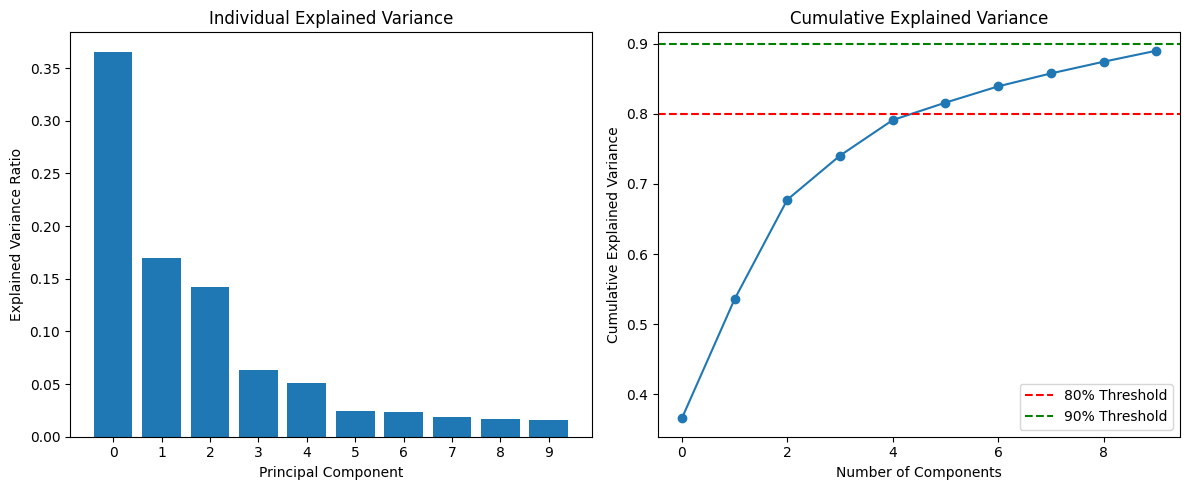

Number of components: 10
Total explained variance: 0.8901
Components needed for 80% variance: 6
Components needed for 90% variance: 1


In [11]:
# PCA
pca_data: np.ndarray
pca_obj: PCA
pca_data, pca_obj = apply_pca(DATA_SCALED, n_components=10, feature_cols=FEATURE_COLS)

In [ ]:
# print(dir(pca_obj))
# print(pca_obj._repr_html_())
display(pca_obj)

PCA(n_components=10, random_state=0)

In [ ]:
# save some data
DATA_SCALED.write_ndjson(Path("../data/features/features_scaled.jsonl"))
dbg_tensor(pca_data)
np.save("../data/features/pca_data.npy", pca_data)

# only columns that start with "activation."
data_meta: pl.DataFrame = DATA_SCALED[[
	col for col in DATA_SCALED.columns if col.startswith("activation.")
]]
data_meta = data_meta.write_ndjson(Path("../data/features/features_meta.jsonl"))

[ <ipykernel>:3 ] pca_data: μ=0.00 σ=3.52 x̃=-0.07 R=[-35.88,27.20] ℙ=|   █▆  | shape=(104416,10) dtype=float64


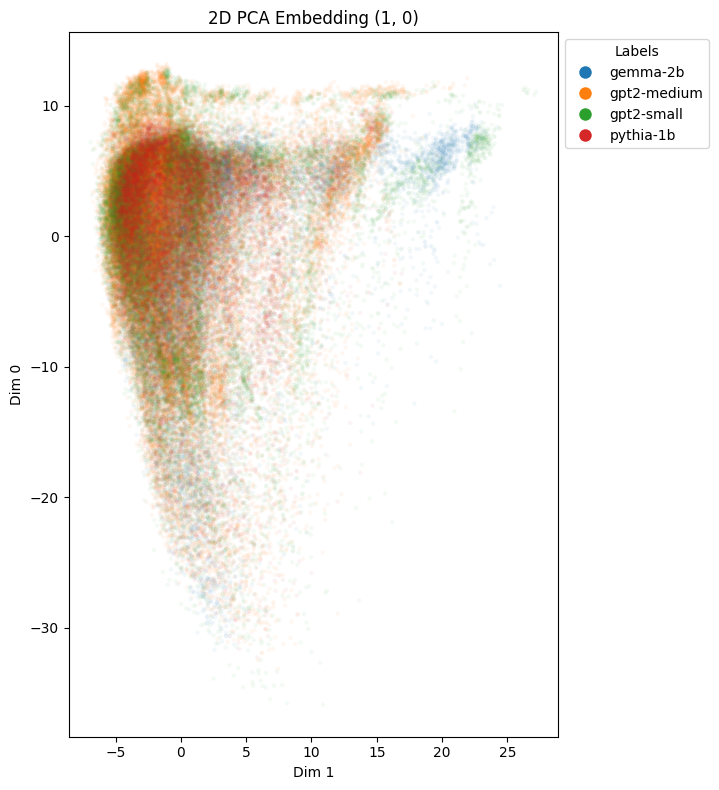

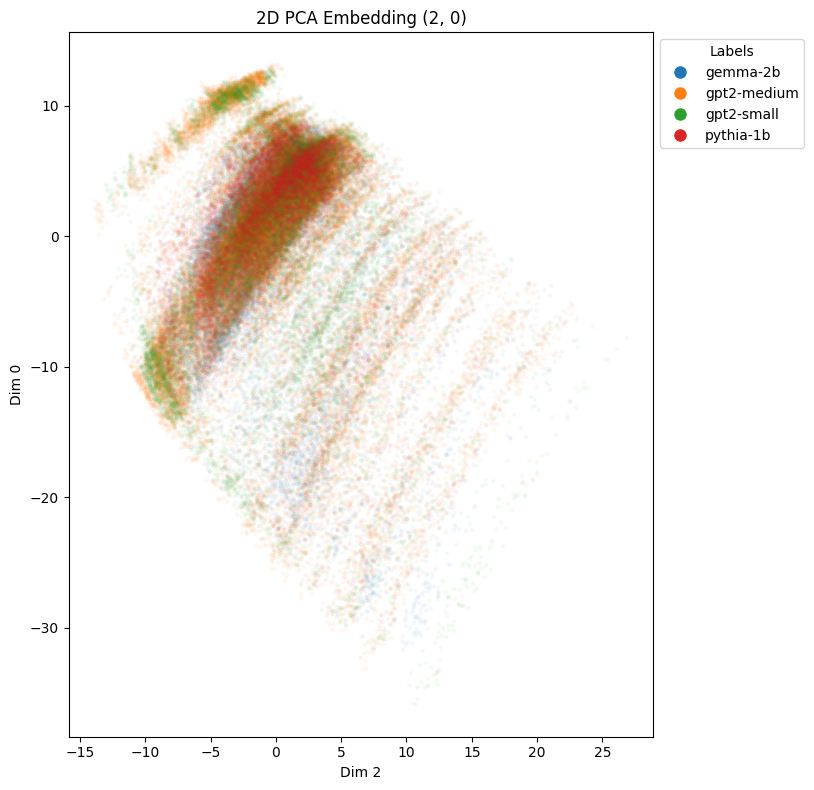

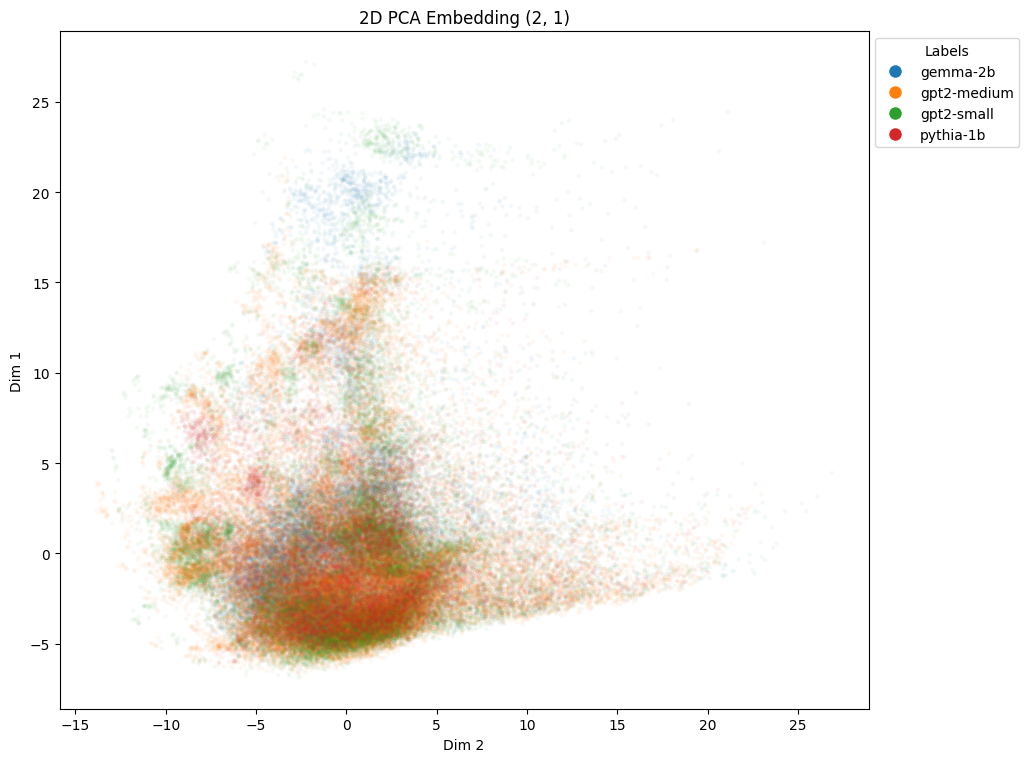

In [ ]:
for i in range(1, 3):
	for j in range(0, i):
		plot_embedding(
			pca_data,
			DATA_SCALED["activation.model"],
			(i, j),
			alpha=0.05,
			marker_size=10,
			title=f"2D PCA Embedding ({i}, {j})",
		)

/home/miv/projects/attn/attention-motifs/attention_motifs/features/plotting.py:331: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Labels", loc="upper left", bbox_to_anchor=(1, 1))


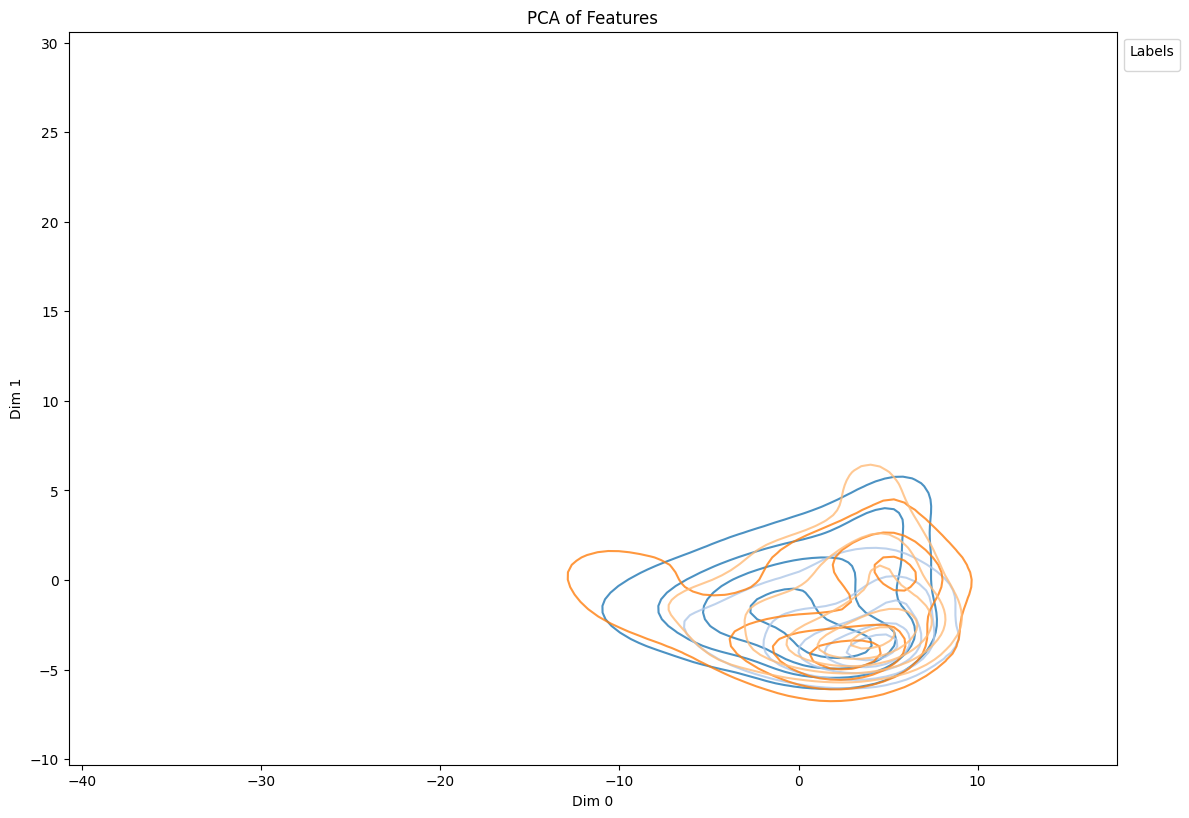

In [15]:
from attention_motifs.features.plotting import plot_embedding_kde
plot_embedding_kde(pca_data[:, :2], DATA_SCALED["activation.model"], "PCA of Features")

In [16]:
def apply_tsne(
	data: pl.DataFrame, n_components: int = 2, perplexity: float = 30.0
) -> np.ndarray:
	"""Compute t-SNE."""
	tsne: TSNE = TSNE(n_components=n_components, perplexity=perplexity, random_state=0)
	embedded: np.ndarray = tsne.fit_transform(data)
	return embedded


def cluster_kmeans(data: np.ndarray, n_clusters: int) -> np.ndarray:
	"""Cluster with K-Means."""
	kmeans: KMeans = KMeans(n_clusters=n_clusters, random_state=0)
	labels: np.ndarray = kmeans.fit_predict(data)
	return labels

# main_example(DATA_NANLESS)

In [17]:
def create_hover_template(hover_cols: list[str]) -> str:
    """Create the hover template for scatter points.
    
    # Parameters:
     - `hover_cols : list[str]`
        List of column names to include in hover information
        
    # Returns:
     - `str`
        A formatted hover template string
    """
    template = "<b>Point Info</b><br>"
    for i, col in enumerate(hover_cols):
        template += f"{col}: %{{customdata[{i}]}}<br>"
    template += f"color value: %{{customdata[{len(hover_cols)}]}}<br>"
    template += "x: %{x:.2f}<br>y: %{y:.2f}<br>z: %{z:.2f}"
    return template


def get_marker_dict(
    color: Union[str, list[str], np.ndarray],
    opacity: float,
    size: int,
    marker_options: Optional[dict[str, Any]] = None,
    **kwargs
) -> dict[str, Any]:
    """Create a marker dictionary with consistent defaults.
    
    # Parameters:
     - `color : Union[str, list[str], np.ndarray]`
        Color or colors for markers
     - `opacity : float`
        Opacity value for markers
     - `size : int`
        Size of markers
     - `marker_options : Optional[dict[str, Any]]`
        Additional marker options to override defaults
     - `**kwargs`
        Any additional key-value pairs to override options
        
    # Returns:
     - `dict[str, Any]`
        A complete marker configuration dictionary
    """
    if marker_options is None:
        marker_options = {}
        
    # Create the base marker dictionary
    marker = {
        'size': size,
        'color': color,
        'opacity': opacity,
    }
    
    # Add default line properties - using rgba with 0 alpha instead of 'transparent'
    if 'line' not in marker_options:
        marker['line'] = {'width': 0, 'color': 'rgba(0,0,0,0)'}
    
    # Add any other marker options
    for k, v in marker_options.items():
        marker[k] = v
        
    # Override with any specific kwargs
    for k, v in kwargs.items():
        marker[k] = v
        
    return marker


def add_scatter_trace(
    fig: go.Figure, 
    df_subset: pd.DataFrame, 
    marker_kwargs: dict[str, Any],
    name: str,
    custom_data_cols: list[str],
    hover_template: str,
    showlegend: bool = True,
    **kwargs
) -> None:
    """Add a scatter trace to the figure with consistent parameters.
    
    # Parameters:
     - `fig : go.Figure`
        The plotly figure to add the trace to
     - `df_subset : pd.DataFrame`
        DataFrame containing the data for this trace
     - `marker_kwargs : dict[str, Any]`
        Keyword arguments for marker configuration
     - `name : str`
        Name of the trace (for legend)
     - `custom_data_cols : list[str]`
        List of columns to include in custom data
     - `hover_template : str`
        Template string for hover information
     - `showlegend : bool`
        Whether to show this trace in the legend
     - `**kwargs`
        Additional keyword arguments for go.Scatter3d
        
    # Modifies:
     - `fig` : Adds a new trace to the figure
    """
    fig.add_trace(go.Scatter3d(
        x=df_subset['x'],
        y=df_subset['y'],
        z=df_subset['z'],
        mode='markers',
        marker=marker_kwargs,
        customdata=df_subset[custom_data_cols].values,
        hovertemplate=hover_template,
        name=name,
        showlegend=showlegend,
        **kwargs
    ))


def plot_embedding_3d_interactive(
    embedding: np.ndarray,
    df: pl.DataFrame,
    color_series: pl.Series,
    hover_cols: list[str],
    select_col: Optional[str] = None,
    dims: tuple[int, int, int] = (0, 1, 2),
    title: str = "3D PCA Embedding",
    alpha: float = 0.8,
    marker_size: int = 5,
    opacity_selected: float = 1.0,
    opacity_unselected: float = 0.3,  # Increased from 0.2 for better visibility
    layout_options: Optional[dict[str, Any]] = None,
    marker_options: Optional[dict[str, Any]] = None,
    selection_colors: Optional[list[str]] = None,  # Changed from selected_color to selection_colors
    unselected_colors: Optional[list[str]] = None,
    debug: bool = True,
    use_reloader: bool = False,
) -> None:
    """Create an interactive 3D scatter plot with points colored by one column
    and hover info from multiple columns. Allows clicking to select multiple points.
    
    # Parameters:
     - `embedding : np.ndarray`
        Embedding array with shape (n_samples, n_components)
     - `df : pl.DataFrame`
        DataFrame containing color and hover columns
     - `color_series : pl.Series`
        Series to use for coloring points
     - `hover_cols : list[str]`
        List of column names to include in hover information
     - `select_col : Optional[str]`
        Column to use for selection/filtering on click (defaults to None)
     - `dims : tuple[int, int, int]`
        Dimensions to plot (defaults to (0, 1, 2))
     - `title : str`
        Plot title (defaults to "3D PCA Embedding")
     - `alpha : float`
        Transparency of points (defaults to 0.8)
     - `marker_size : int`
        Size of markers (defaults to 5)
     - `opacity_selected : float`
        Opacity for selected points (defaults to 1.0)
     - `opacity_unselected : float`
        Opacity for unselected points (defaults to 0.3)
     - `layout_options : Optional[dict[str, Any]]`
        Additional layout options to pass to fig.update_layout
     - `marker_options : Optional[dict[str, Any]]`
        Additional marker options to override defaults
     - `selection_colors : Optional[list[str]]`
        Colors to use for multiple selected groups (defaults to px.colors.qualitative.D3)
     - `unselected_colors : Optional[list[str]]`
        Colors for unselected points (defaults to ['rgb(0, 0, 255)'])
     - `debug : bool`
        Whether to run the Dash app in debug mode (defaults to True)
     - `use_reloader : bool`
        Whether to use the reloader when running the Dash app (defaults to False)
    """
    # Default values for optional parameters
    if unselected_colors is None:
        unselected_colors = ['rgb(0, 0, 255)']  # Single default color
    
    # Use D3 color scheme for selections if not provided
    if selection_colors is None:
        selection_colors = px.colors.qualitative.D3
    
    if layout_options is None:
        layout_options = {}
    
    # Set default marker options but don't override user-provided ones
    if marker_options is None:
        marker_options = {}
    
    # Create a DataFrame with all the necessary data
    plot_data = {
        'x': embedding[:, dims[0]],
        'y': embedding[:, dims[1]],
        'z': embedding[:, dims[2]],
        'color': color_series.to_numpy(),
    }
    
    # Add hover columns
    for col in hover_cols:
        plot_data[col] = df[col].to_numpy()
        
    # Add selection column if specified and not already added
    if select_col and select_col not in plot_data and select_col not in hover_cols:
        plot_data[select_col] = df[select_col].to_numpy()
        
    # Create pandas DataFrame for plotly
    plot_df = pd.DataFrame(plot_data)
    plot_df['color_value'] = plot_df['color']
    plot_df = plot_df.reset_index(drop=True)
    
    # Prepare custom data columns for hover
    custom_data_cols = hover_cols + ['color_value']
    if select_col and select_col not in custom_data_cols:
        custom_data_cols.append(select_col)
    
    # Create the hover template
    hover_template = create_hover_template(hover_cols)
    
    # Create a Dash app
    app = Dash(__name__)
    
    # Create the figure creation function
    def create_figure(selected_values: Optional[list[Any]] = None) -> go.Figure:
        """Create a 3D scatter plot figure with support for multiple selections."""
        # Determine title based on selection
        if selected_values and len(selected_values) > 0:
            title_text = f"{title} - Selected: {', '.join(str(v) for v in selected_values)}"
        else:
            title_text = title
        
        # Create the figure
        fig = go.Figure()
        
        # Handle selection
        if selected_values and len(selected_values) > 0 and select_col is not None:
            # Create a combined mask for all non-selected points
            non_selected_mask = ~plot_df[select_col].isin(selected_values)
            non_selected_df = plot_df[non_selected_mask]
            
            # Check if color series is categorical
            is_categorical = isinstance(plot_df['color'].iloc[0], (str, bool))
            if is_categorical:
                # Add non-selected points with low visibility
                for i, color in enumerate(unselected_colors):
                    marker_dict = get_marker_dict(
                        color=color, 
                        opacity=opacity_unselected, 
                        size=marker_size,
                        marker_options=marker_options
                    )
                    
                    add_scatter_trace(
                        fig=fig,
                        df_subset=non_selected_df,
                        marker_kwargs=marker_dict,
                        name="Other Points",
                        custom_data_cols=custom_data_cols,
                        hover_template=hover_template,
                        showlegend=(i == 0)  # Only show legend for the first trace
                    )
                
                # Add each selected group with a distinct color
                for i, selected_value in enumerate(selected_values):
                    # Use modulo to cycle through colors if we have more selections than colors
                    color_index = i % len(selection_colors)
                    selected_color = selection_colors[color_index]
                    
                    selected_mask = plot_df[select_col] == selected_value
                    selected_df = plot_df[selected_mask]
                    
                    marker_dict = get_marker_dict(
                        color=selected_color, 
                        opacity=opacity_selected, 
                        size=marker_size,
                        marker_options=marker_options
                    )
                    
                    add_scatter_trace(
                        fig=fig,
                        df_subset=selected_df,
                        marker_kwargs=marker_dict,
                        name=f"Selected: {selected_value}",
                        custom_data_cols=custom_data_cols,
                        hover_template=hover_template
                    )
            else:
                raise ValueError(f"Color series must be categorical (str or bool) for selection, got {type(plot_df['color'].iloc[0])}")
        else:
            # Just show all points normally - handle categorical data
            if isinstance(plot_df['color'].iloc[0], (str, bool)):
                # Handle categorical data by creating a color mapping
                unique_values = plot_df['color'].unique()
                # Use plotly's qualitative colorscale
                color_scale = px.colors.qualitative.Plotly
                color_map = {val: color_scale[i % len(color_scale)] for i, val in enumerate(unique_values)}
                
                # Add a trace for each unique value to get proper legend
                for val in unique_values:
                    mask = plot_df['color'] == val
                    marker_dict = get_marker_dict(
                        color=color_map[val], 
                        opacity=alpha, 
                        size=marker_size,
                        marker_options=marker_options
                    )
                    
                    add_scatter_trace(
                        fig=fig,
                        df_subset=plot_df.loc[mask],
                        marker_kwargs=marker_dict,
                        name=str(val),
                        custom_data_cols=custom_data_cols,
                        hover_template=hover_template
                    )
            else:
                # For numeric data
                marker_dict = get_marker_dict(
                    color=plot_df['color'], 
                    opacity=alpha, 
                    size=marker_size,
                    marker_options=marker_options
                )
                
                add_scatter_trace(
                    fig=fig,
                    df_subset=plot_df,
                    marker_kwargs=marker_dict,
                    name="Points",
                    custom_data_cols=custom_data_cols,
                    hover_template=hover_template
                )
                
        # Default layout options
        default_layout = {
            'title': {
                'text': title_text,
                'y': 0.95,
                'x': 0.5,
                'xanchor': 'center',
                'yanchor': 'top'
            },
            'scene': {
                'xaxis_title': f'Dimension {dims[0]}',
                'yaxis_title': f'Dimension {dims[1]}',
                'zaxis_title': f'Dimension {dims[2]}',
            },
            'legend': {
                'itemsizing': 'constant',
                'bgcolor': 'rgba(255, 255, 255, 0.8)'
            }
        }
        
        # Merge with user-provided layout options
        merged_layout = {**default_layout, **layout_options}
        fig.update_layout(**merged_layout)
        
        return fig
    
    # Set up the layout
    app.layout = html.Div([
        html.H1(title),
        dcc.Graph(
            id='embedding-plot',
            figure=create_figure(),
            config={'displayModeBar': True}
        ),
        html.Button("Clear Selection", id="clear-button", n_clicks=0),
        html.Div([
            html.H3("Selected Values:"),
            html.Div(id="selection-display", style={'marginBottom': '10px'})
        ]),
        dcc.Store(id="selected-values", data=[])  # Changed to store a list of values
    ])
    
    # Define callback for displaying selected values
    @app.callback(
        Output('selection-display', 'children'),
        Input('selected-values', 'data')
    )
    def update_selection_display(selected_values):
        """Update the display of selected values."""
        if not selected_values or len(selected_values) == 0:
            return "None"
        
        # Create a list of colored labels
        labels = []
        for i, val in enumerate(selected_values):
            color_index = i % len(selection_colors)
            color = selection_colors[color_index]
            labels.append(html.Span(
                str(val),
                style={'color': color, 'fontWeight': 'bold', 'marginRight': '10px'}
            ))
            
        return labels
    
    # Define callback for interactivity
    @app.callback(
        Output('embedding-plot', 'figure'),
        Output('selected-values', 'data'),
        Input('embedding-plot', 'clickData'),
        Input('clear-button', 'n_clicks'),
        State('selected-values', 'data')
    )
    def update_plot(click_data, clear_clicks, stored_values):
        """Update the plot based on user interaction with multi-selection support."""
        ctx = callback_context
        triggered_id = ""
        
        if ctx.triggered:
            triggered_id = ctx.triggered[0]['prop_id'].split('.')[0]
        
        # Initialize selections if None
        if stored_values is None:
            stored_values = []
        
        # Handle clear button click
        if triggered_id == "clear-button":
            return create_figure(), []
        
        # Handle point selection
        if click_data is not None and select_col is not None:
            point = click_data['points'][0]
            
            # Find the selection column value
            # Look for the column in the customdata array if it exists
            select_col_index = None
            if select_col in custom_data_cols:
                select_col_index = custom_data_cols.index(select_col)
            
            # Get the clicked value
            if select_col_index is not None and 'customdata' in point:
                clicked_value = point['customdata'][select_col_index]
                
                # Print the selected value to the console
                print(f"Selected value in '{select_col}': {clicked_value}")
                
                # Toggle selection: if already selected, remove it; otherwise add it
                if clicked_value in stored_values:
                    stored_values.remove(clicked_value)
                    print(f"Removed '{clicked_value}' from selection. Current selection: {stored_values}")
                else:
                    stored_values.append(clicked_value)
                    print(f"Added '{clicked_value}' to selection. Current selection: {stored_values}")
                
                return create_figure(stored_values), stored_values
        
        # Default return (initial load or no change)
        return create_figure(stored_values), stored_values
    
    # Start the app
    app.run(debug=debug, use_reloader=use_reloader)


plot_embedding_3d_interactive(
    embedding=pca_data,
    df=DATA_SCALED,
    color_series=DATA_SCALED["activation.model"],
    hover_cols=["activation.cls", "activation.prompt"],
    select_col="activation.cls",  # Column to use for selection
    dims=(0, 1, 2),
    title="PCA Embedding by Model Type",
    alpha=0.1,
    marker_size=2,
    opacity_unselected=0.4,
    # Using D3 qualitative color scheme for selections
    selection_colors=px.colors.qualitative.D3,
    unselected_colors=['rgba(50, 50, 200, 0.5)'],  # blue color for unselected
    layout_options={
        'scene': {
            'camera': {'eye': {'x': 1.5, 'y': 1.5, 'z': 1.5}},
            'aspectmode': 'cube'
        }
    },
    marker_options={
        'symbol': 'circle',
    }
)